In [ ]:
from pathlib import Path
from datetime import datetime
import subprocess
import pandas as pd
from IPython.display import display

# CALC_METRICS pre-check (aligned with nf; fixed min_ac=0)
CONFIG = {
    'GTPath': '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/wgs.auto.par/results',
    'InfoPath': '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/info/cteph_agp3k.v6.20260507.xlsx',
    'ScriptDir': '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/scripts',
    'Plink2': '/home/b/b37974/plink2_alpha6/plink2',
    'Tabix': '/home/b/b37974/htslib-1.9/tabix',
    'IDCol': 'ID_JHRPv6',
    'GroupCol': 'Outcome',
    'CaseValue': 'PH',
    'TdpCol': 'Target_Depth',
    'MdpCol': 'Observed_Depth',
    'ThreadsCalc': 4,
}

MIN_AC = 0
WORK_DIR = Path('/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/pre_check/results/00_minac0')
WORK_DIR.mkdir(parents=True, exist_ok=True)


def first_existing(paths):
    return next((p for p in paths if p.exists()), None)


def build_cmd(cfg: dict, min_ac: int):
    bed_prefix = (
        f"{cfg['GTPath']}/14_fixed_model_prep/"
        'cteph_agp3k_v6_wgs_merged.sample_qc.variant_qc.popgmm.fixed_model.maf_lt_threshold'
    )
    return [
        'bash', f"{cfg['ScriptDir']}/run_calc_metrics.sh",
        '--bed-prefix', bed_prefix,
        '--info-file', cfg['InfoPath'],
        '--out-sample', 'sample_metrics.txt',
        '--out-variant', 'variant_metrics.txt',
        '--script-dir', cfg['ScriptDir'],
        '--plink2', cfg['Plink2'],
        '--tabix', cfg['Tabix'],
        '--id-col', cfg['IDCol'],
        '--group-col', cfg['GroupCol'],
        '--case-value', cfg['CaseValue'],
        '--tdp-col', cfg['TdpCol'],
        '--mdp-col', cfg['MdpCol'],
        '--min-ac', str(min_ac),
        '--threads', str(cfg['ThreadsCalc']),
    ]


# Run
cmd = build_cmd(CONFIG, MIN_AC)
t0 = datetime.now()
res = subprocess.run(cmd, cwd=WORK_DIR, capture_output=True, text=True)
t1 = datetime.now()

if res.returncode != 0:
    err_tail = '\n'.join(res.stderr.strip().splitlines()[-60:]) if res.stderr.strip() else '(no stderr)'
    raise RuntimeError(f'CALC_METRICS failed (code={res.returncode})\n--- stderr tail ---\n{err_tail}')

# Outputs
sample_metrics_path = first_existing([WORK_DIR / 'sample_metrics.txt.gz', WORK_DIR / 'sample_metrics.txt'])
variant_metrics_path = first_existing([WORK_DIR / 'variant_metrics.txt.gz', WORK_DIR / 'variant_metrics.txt'])
variant_tbi_path = WORK_DIR / 'variant_metrics.txt.gz.tbi'
log_path = WORK_DIR / 'calc_metrics.log'

run_summary = pd.DataFrame([
    {'item': 'status', 'value': 'success'},
    {'item': 'min_ac', 'value': MIN_AC},
    {'item': 'duration_sec', 'value': round((t1 - t0).total_seconds(), 1)},
    {'item': 'work_dir', 'value': str(WORK_DIR)},
])

file_rows = []
for label, path_obj in [
    ('sample_metrics', sample_metrics_path),
    ('variant_metrics', variant_metrics_path),
    ('variant_metrics_tbi', variant_tbi_path),
    ('calc_metrics_log', log_path),
]:
    exists = path_obj is not None and Path(path_obj).exists()
    size_mb = (Path(path_obj).stat().st_size / (1024 * 1024)) if exists else None
    file_rows.append({
        'file': label,
        'exists': bool(exists),
        'size_mb': round(size_mb, 3) if size_mb is not None else None,
        'path': str(path_obj) if path_obj is not None else 'NOT FOUND',
    })

file_check = pd.DataFrame(file_rows)

# Minimal output
print('CALC_METRICS pre-check finished.')
display(run_summary)
display(file_check)


Outlier threshold (|robust z|): 3
Outlier samples: 26
Outlier file   : /LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/pre_check/results/01_outliers_z3/outliers_sminac_robustz.remove.txt


,robust_z_threshold,n_removed,n_retained,retained_fraction,spearman_rho,spearman_p
0,1.0,1004,2056,0.671895,0.198062,1.243326e-19
1,1.5,423,2637,0.861765,0.248485,2.120746e-38
2,2.0,155,2905,0.949346,0.293555,7.835484e-59
3,2.5,63,2997,0.979412,0.311225,2.581574e-68
4,3.0,26,3034,0.991503,0.318683,1.401205e-72
5,3.5,12,3048,0.996078,0.326025,2.072498e-76
6,4.0,5,3055,0.998366,0.329967,1.655222e-78
7,4.5,5,3055,0.998366,0.329967,1.655222e-78
8,5.0,3,3057,0.999020,0.330674,6.608421e-79
9,5.5,3,3057,0.999020,0.330674,6.608421e-79


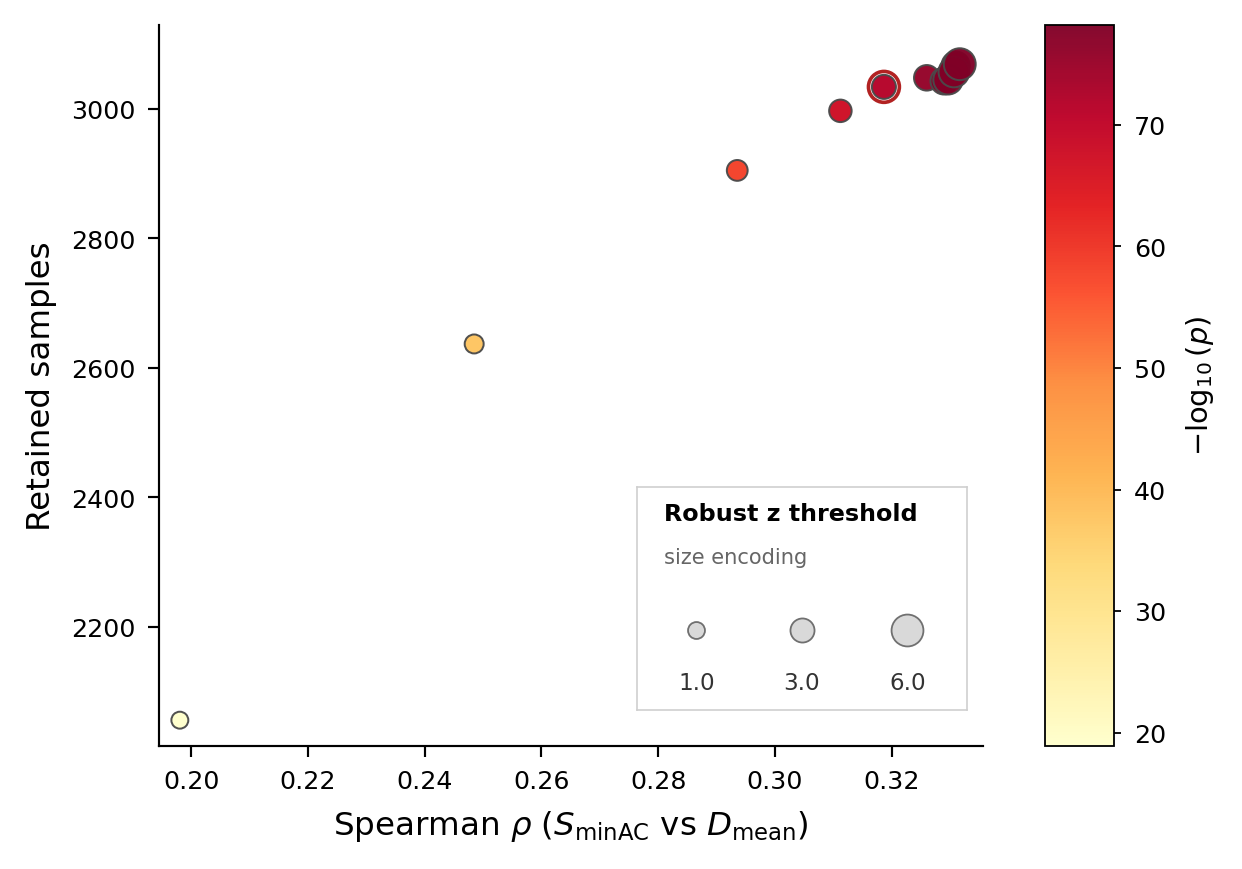

In [13]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from IPython.display import display

# =========================
# 1) Parameters
# =========================
Z_THRESHOLD = 3.0  # user-defined outlier cutoff on |robust z|
THRESHOLD_GRID = np.arange(1.0, 6.5, 0.5)
THRESHOLD_GRID = np.unique(np.round(THRESHOLD_GRID, 2))

OUT_DIR_01 = WORK_DIR.parent / f'01_outliers_z{Z_THRESHOLD:g}'
OUT_DIR_01.mkdir(parents=True, exist_ok=True)
OUTLIER_FILE = OUT_DIR_01 / 'outliers_sminac_robustz.remove.txt'


# =========================
# 2) Load + Robust-z Compute
# =========================
if 'sample_metrics_path' not in globals() or sample_metrics_path is None:
    fallback = WORK_DIR / 'sample_metrics.txt.gz'
    if fallback.exists():
        sample_metrics_path = fallback
    else:
        raise FileNotFoundError('sample_metrics_path is missing. Please run Cell 1 first.')

plot_source_df = pd.read_csv(sample_metrics_path, sep='\t', compression='infer').copy()
required_cols = ['SMinAC', 'MeanDP', 'SampleID']
missing_cols = [c for c in required_cols if c not in plot_source_df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in sample_metrics: {missing_cols}')

sminac_num = pd.to_numeric(plot_source_df['SMinAC'], errors='coerce')
median_sminac = float(np.nanmedian(sminac_num))
mad_sminac = float(np.nanmedian(np.abs(sminac_num - median_sminac)))

if np.isnan(mad_sminac) or mad_sminac == 0:
    plot_source_df['SMinAC_robust_z_abs'] = np.nan
else:
    plot_source_df['SMinAC_robust_z_abs'] = np.abs(0.6745 * (sminac_num - median_sminac) / mad_sminac)


# =========================
# 3) Export Outliers (FID IID)
# =========================
outlier_mask = plot_source_df['SMinAC_robust_z_abs'] > Z_THRESHOLD
outlier_ids = plot_source_df.loc[outlier_mask, 'SampleID'].astype(str)

with open(OUTLIER_FILE, 'w') as f:
    for sid in outlier_ids:
        f.write(f"{sid}\t{sid}\n")


# =========================
# 4) Threshold Sensitivity Scan
# =========================
scan_rows = []
for threshold in THRESHOLD_GRID:
    keep_mask = (
        plot_source_df['SMinAC_robust_z_abs'].isna()
        | (plot_source_df['SMinAC_robust_z_abs'] <= threshold)
    )
    kept_df = plot_source_df.loc[keep_mask].copy()
    removed_n = int((~keep_mask).sum())
    retained_n = int(keep_mask.sum())

    corr_df_thr = kept_df.dropna(subset=['SMinAC', 'MeanDP'])
    if len(corr_df_thr) > 1:
        rho_thr, p_thr = stats.spearmanr(corr_df_thr['SMinAC'], corr_df_thr['MeanDP'])
    else:
        rho_thr, p_thr = np.nan, np.nan

    scan_rows.append({
        'robust_z_threshold': threshold,
        'n_removed': removed_n,
        'n_retained': retained_n,
        'retained_fraction': retained_n / len(plot_source_df),
        'spearman_rho': rho_thr,
        'spearman_p': p_thr,
    })

threshold_scan_df = pd.DataFrame(scan_rows).sort_values('robust_z_threshold').reset_index(drop=True)

print(f'Outlier threshold (|robust z|): {Z_THRESHOLD:g}')
print(f'Outlier samples: {len(outlier_ids)}')
print(f'Outlier file   : {OUTLIER_FILE}')
display(threshold_scan_df)


# =========================
# 5) Plot (style aligned with tmp cell6)
# =========================
plot_df = threshold_scan_df.copy()
plot_df['plot_x'] = plot_df['spearman_rho']
plot_df['plot_y'] = plot_df['n_retained']

for _, grp in plot_df.groupby(['spearman_rho', 'n_retained']):
    if len(grp) > 1:
        x_offsets = np.linspace(-0.0010, 0.0010, len(grp))
        y_offsets = np.linspace(-12, 12, len(grp))
        plot_df.loc[grp.index, 'plot_x'] = grp['spearman_rho'].iloc[0] + x_offsets
        plot_df.loc[grp.index, 'plot_y'] = grp['n_retained'].iloc[0] + y_offsets

plot_df['log10_p'] = -np.log10(plot_df['spearman_p'].clip(lower=float(np.finfo(float).tiny)))

z_min, z_max = plot_df['robust_z_threshold'].min(), plot_df['robust_z_threshold'].max()
s_min, s_max = 22, 78
plot_df['point_size'] = s_min + (plot_df['robust_z_threshold'] - z_min) / (z_max - z_min) * (s_max - s_min)

highlight_z = Z_THRESHOLD
legend_z_vals = [z for z in [1.0, 3.0, 6.0] if z_min <= z <= z_max]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.linewidth': 0.6,
    'axes.labelsize': 9,
    'axes.labelweight': 'normal',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'xtick.major.width': 0.6,
    'xtick.major.size': 3.0,
    'ytick.major.width': 0.6,
    'ytick.major.size': 3.0,
    'figure.dpi': 260,
    'savefig.dpi': 900,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

fig = plt.figure(figsize=(4.8, 4.2), facecolor='white')
left, bottom, size = 0.13, 0.14, 0.66
cbar_left, cbar_w = 0.84, 0.055

ax = fig.add_axes([left, bottom, size, size], facecolor='white')
cax = fig.add_axes([cbar_left, bottom, cbar_w, size], facecolor='white')

scatter = ax.scatter(
    plot_df['plot_x'],
    plot_df['plot_y'],
    s=plot_df['point_size'],
    c=plot_df['log10_p'],
    cmap='YlOrRd',
    edgecolors='#4A4A4A',
    linewidths=0.55,
    alpha=0.96,
    vmin=plot_df['log10_p'].min(),
    vmax=plot_df['log10_p'].max(),
)

ax.set_xlabel(r'Spearman $\rho$ ($S_{\mathrm{minAC}}$ vs $D_{\mathrm{mean}}$)', labelpad=4, color='black')
ax.set_ylabel('Retained samples', labelpad=4, color='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', length=3.0, width=0.6, direction='out', colors='black')
ax.set_xlim(plot_df['plot_x'].min() - 0.0035, plot_df['plot_x'].max() + 0.0040)
ax.set_ylim(plot_df['plot_y'].min() - 40, plot_df['plot_y'].max() + 60)

cbar = fig.colorbar(scatter, cax=cax)
cbar.set_label(r'$-\log_{10}(p)$', fontsize=8, labelpad=5, color='black')
cbar.ax.tick_params(labelsize=7, length=2.0, width=0.5, colors='black')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.5)

legend_ax = ax.inset_axes([0.58, 0.05, 0.40, 0.31])
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.95)
for spine in legend_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.45)
    spine.set_edgecolor('#CFCFCF')  # type: ignore[attr-defined]

legend_ax.text(0.08, 0.93, 'Robust z threshold', fontsize=6.6, weight='semibold', ha='left', va='top', color='black')
legend_ax.text(0.08, 0.73, 'size encoding', fontsize=5.8, ha='left', va='top', color='#666666')

legend_sizes = [s_min + (z - z_min) / (z_max - z_min) * (s_max - s_min) for z in legend_z_vals]
for x_pos, z_val, s_val in zip([0.18, 0.50, 0.82], legend_z_vals, legend_sizes):
    legend_ax.scatter(x_pos, 0.36, s=s_val, c='#D9D9D9', edgecolors='#707070', linewidths=0.5, alpha=1.0)
    legend_ax.text(x_pos, 0.07, f'{z_val:.1f}', fontsize=6.4, va='bottom', ha='center', color='#333333')

if highlight_z is not None:
    hit = plot_df[plot_df['robust_z_threshold'] == highlight_z]
    if not hit.empty:
        h_x = hit['plot_x'].values[0]
        h_y = hit['plot_y'].values[0]
        h_z = hit['robust_z_threshold'].values[0]
        h_size = hit['point_size'].values[0]

        ax.scatter([h_x], [h_y], s=h_size * 1.65, facecolors='none', edgecolors='#B22222', linewidths=1.0, zorder=14)
        # ax.annotate(
        #     f'$z$ = {h_z:.1f}',
        #     xy=(h_x, h_y),
        #     xytext=(-12, -18),
        #     textcoords='offset points',
        #     fontsize=8,
        #     weight='semibold',
        #     color='#B22222',
        #     bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#B22222', linewidth=0.7, alpha=0.98),
        #     arrowprops=dict(arrowstyle='->', color='#B22222', lw=0.7, shrinkA=6, shrinkB=5, mutation_scale=7),
        #     ha='right',
        #     va='top',
        #     zorder=15,
        # )

plt.show()


SMinAC robust z outliers (|z| > 3): 26


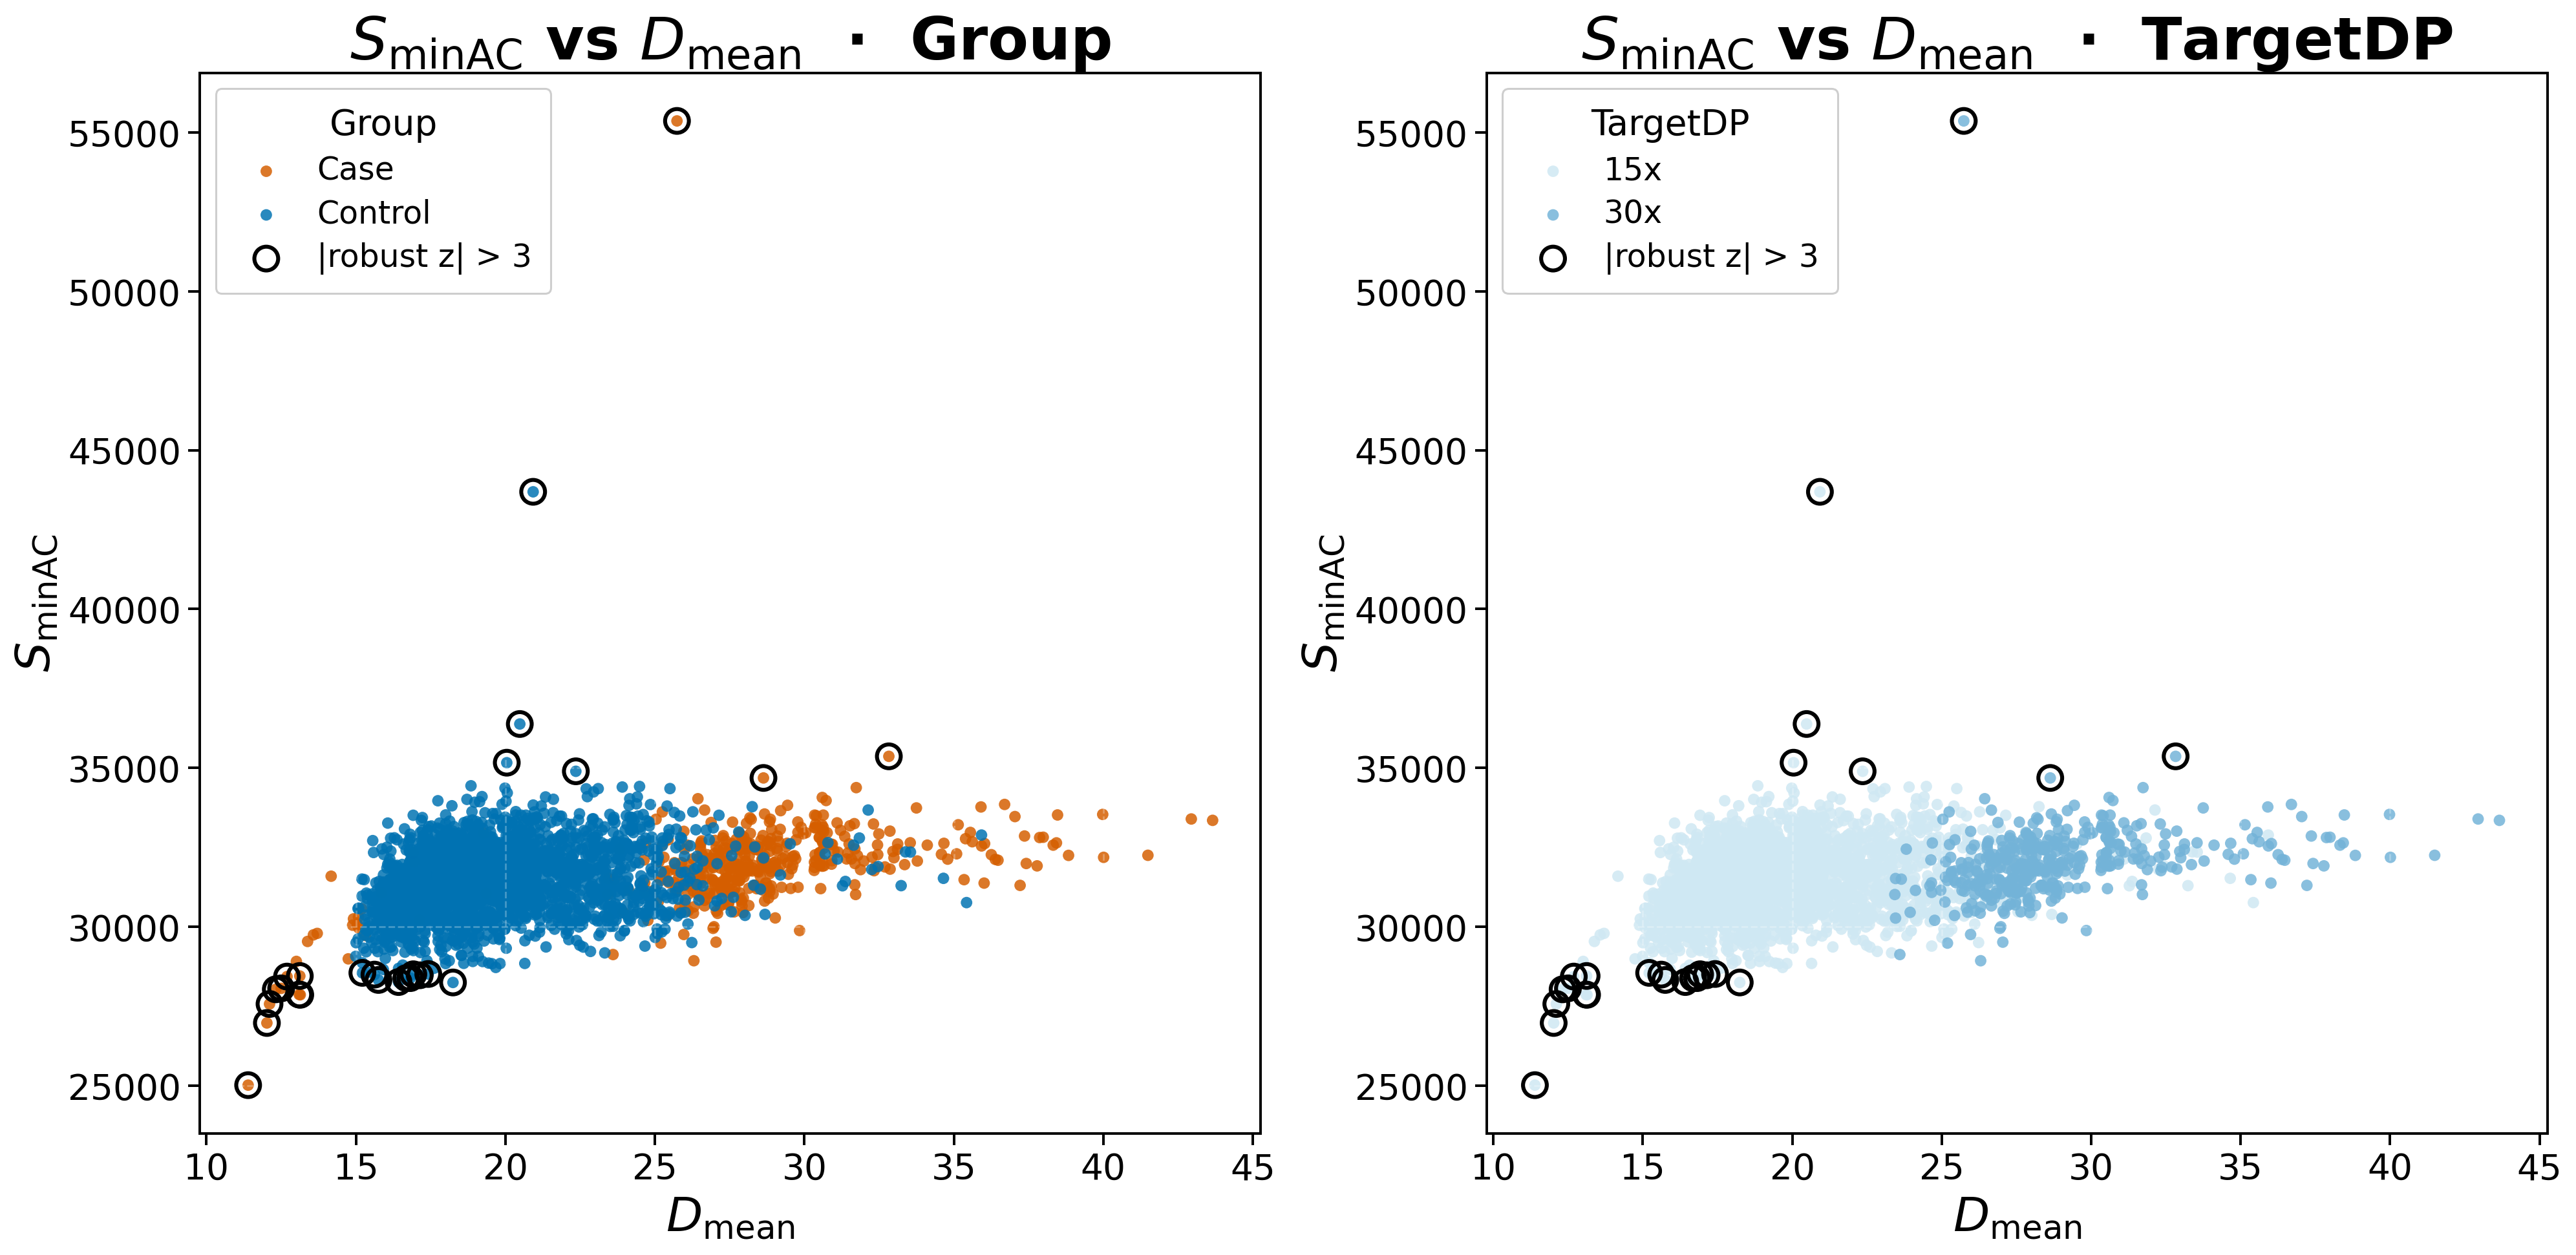

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================
# 1) Parameters
# =========================
ROBUST_Z_THRESHOLD = 3.0  # |robust z| cutoff for SMinAC outlier marking

# Colorblind-safe palettes (Wong 2011)
GROUP_COLORS   = {'Case': '#D55E00', 'Control': '#0072B2', 'NaN': '#7F7F7F'}
GROUP_FALLBACK = ['#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#F0E442']
TARGETDP_GRADIENT = ['#CFE8F3', '#73B3D8', '#2878B5', '#0F4C81']

# =========================
# 2) Load Data
# =========================
if 'sample_metrics_path' not in globals() or sample_metrics_path is None:
    _src = WORK_DIR / 'sample_metrics.txt.gz'
    if not _src.exists():
        raise FileNotFoundError('sample_metrics_path missing. Run Cell 1 first.')
else:
    _src = sample_metrics_path

df = pd.read_csv(_src, sep='\t')
required_cols = ['MeanDP', 'SMinAC', 'Group', 'TargetDP']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}')

# =========================
# 3) Robust-z for SMinAC
# =========================
df_plot = df.copy()
sminac_num = pd.to_numeric(df_plot['SMinAC'], errors='coerce')
median_sminac = float(np.nanmedian(sminac_num))
mad_sminac    = float(np.nanmedian(np.abs(sminac_num - median_sminac)))

if np.isnan(mad_sminac) or mad_sminac == 0:
    df_plot['SMinAC_robust_z_abs'] = np.nan
else:
    df_plot['SMinAC_robust_z_abs'] = np.abs(0.6745 * (sminac_num - median_sminac) / mad_sminac)

df_plot['SMinAC_is_outlier'] = df_plot['SMinAC_robust_z_abs'] > ROBUST_Z_THRESHOLD
outlier_df = df_plot[df_plot['SMinAC_is_outlier']]
print(f'SMinAC robust z outliers (|z| > {ROBUST_Z_THRESHOLD:g}): {len(outlier_df)}')

# =========================
# 4) Color Maps
# =========================
# Group
group_color_map, _fb = {}, 0
for g in df_plot['Group'].fillna('NaN').astype(str).unique():
    if g in GROUP_COLORS:
        group_color_map[g] = GROUP_COLORS[g]
    else:
        group_color_map[g] = GROUP_FALLBACK[_fb % len(GROUP_FALLBACK)]
        _fb += 1

# TargetDP: numeric → colorbar; categorical → discrete legend
targetdp_is_numeric = pd.api.types.is_numeric_dtype(df_plot['TargetDP'])
if not targetdp_is_numeric:
    levels = list(df_plot['TargetDP'].fillna('NaN').astype(str).unique())
    sort_key = pd.Series(levels).str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)
    sort_df = pd.DataFrame({'level': levels, 'num': sort_key})
    sort_df['_na'] = sort_df['num'].isna()
    levels_sorted = sort_df.sort_values(['_na', 'num', 'level'])['level'].tolist()
    targetdp_color_map = {
        t: ('#7F7F7F' if t == 'NaN' else TARGETDP_GRADIENT[i % len(TARGETDP_GRADIENT)])
        for i, t in enumerate(levels_sorted)
    }

# =========================
# 5) Plot Style
# =========================
plt.rcParams.update({
    'figure.dpi': 220, 'savefig.dpi': 600, 'savefig.bbox': 'tight',
    'font.size': 20, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 30, 'axes.titleweight': 'bold',
    'axes.labelsize': 24, 'axes.labelweight': 'bold',
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 16, 'legend.title_fontsize': 18,
    'axes.linewidth': 1.6,
    'grid.linewidth': 0.9, 'grid.alpha': 0.28, 'grid.linestyle': '--',
    'lines.linewidth': 1.8,
})

SCATTER_KW = dict(s=34, alpha=0.84, edgecolors='none')
OUTLIER_KW = dict(s=145, facecolors='none', edgecolors='black', linewidths=2.0,
                  label=f'|robust z| > {ROBUST_Z_THRESHOLD:g}', zorder=5)
LEGEND_KW  = dict(loc='upper left', frameon=True, framealpha=0.96,
                  borderpad=0.6, handletextpad=0.6, labelspacing=0.4)
x_lbl = r'$D_{\mathrm{mean}}$'
y_lbl = r'$S_{\mathrm{minAC}}$'

# =========================
# 6) Figure
# =========================
fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

for ax in axes:
    ax.set_box_aspect(1)
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.3)
    ax.tick_params(direction='out', length=6, width=1.3)
    ax.grid(True, which='major')

# — Left: color by Group —
for gname, sub in df_plot.groupby('Group', dropna=False):
    lbl = str(gname) if pd.notna(gname) else 'NaN'
    axes[0].scatter(sub['MeanDP'], sub['SMinAC'], color=group_color_map[lbl], label=lbl, **SCATTER_KW)
if not outlier_df.empty:
    axes[0].scatter(outlier_df['MeanDP'], outlier_df['SMinAC'], **OUTLIER_KW)
axes[0].set_title(r'$S_{\mathrm{minAC}}$ vs $D_{\mathrm{mean}}$  ·  Group')
axes[0].set_xlabel(x_lbl)
axes[0].set_ylabel(y_lbl)
axes[0].legend(title='Group', **LEGEND_KW)

# — Right: color by TargetDP —
if targetdp_is_numeric:
    sc = axes[1].scatter(df_plot['MeanDP'], df_plot['SMinAC'],
                         c=df_plot['TargetDP'], cmap='viridis', **SCATTER_KW)
    cbar = fig.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.03)
    cbar.set_label('TargetDP', fontsize=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)
else:
    for tname, sub in df_plot.groupby('TargetDP', dropna=False):
        lbl = str(tname) if pd.notna(tname) else 'NaN'
        axes[1].scatter(sub['MeanDP'], sub['SMinAC'], color=targetdp_color_map[lbl], label=lbl, **SCATTER_KW)
if not outlier_df.empty:
    axes[1].scatter(outlier_df['MeanDP'], outlier_df['SMinAC'], **OUTLIER_KW)
axes[1].set_title(r'$S_{\mathrm{minAC}}$ vs $D_{\mathrm{mean}}$  ·  TargetDP')
axes[1].set_xlabel(x_lbl)
axes[1].set_ylabel(y_lbl)
axes[1].legend(title='TargetDP', **LEGEND_KW)

plt.show()
